*© 2026 Paul Fergus*

# Lab 7 — Training a YOLO26 object detector

**Module:** 7144COMP — Deep Learning Concepts and Techniques  
**Week:** 7  
**Estimated time:** 240 minutes

---

## ⚠ Hardware requirement

**This lab requires a CUDA-capable NVIDIA GPU.** The container is built from a CUDA base image and expects to be run with GPU passthrough enabled (`deploy.resources.devices: nvidia` in `docker-compose.yml`). Tested configurations: RTX 3090 / 4090 / 5090.

If you do not have a GPU, you can still complete the conceptual sections and read through the code, but the training cells will fail at the device-check step.

## Learning outcomes

By the end of this lab you should be able to:

1. Verify GPU availability and select the right device for training.
2. Explain what makes object detection a fundamentally different problem from image classification, and where YOLO sits in the family of detection architectures.
3. Train a YOLO26x detector on a custom YOLO-format dataset using the Ultralytics Python API.
4. Interpret object detection metrics — precision, recall, **mAP50**, **mAP50-95** — and explain what each tells you about model behaviour.
5. Run inference on new images and visualise the resulting bounding boxes with class labels and confidence scores.
6. Export the trained model to ONNX for deployment in non-PyTorch environments.

## Prerequisites

- **Lab 6** completed — your annotated dataset and `data.yaml` are what we'll train on. *If you didn't complete Lab 6 we provide a fallback in Section 2.*
- **Labs 1–5** completed — you should be comfortable with PyTorch, training loops, and evaluation metrics.
- The textbook *Applied Deep Learning* (Fergus & Chalmers), Chapter 7 — object detection.
- Lecture 7: *Single-shot detectors, anchor-free heads, and the post-NMS era of YOLO*.

## The thread from last week

In Lab 6 you produced a clean YOLO-format dataset: images on disk, bounding-box annotations in `.txt` files, a `data.yaml` that ties it all together. **This week we use that dataset to train a real, production-grade object detector.** Everything we've built across six weeks — tensor mechanics, training loops, augmentation, CNN architecture — converges here.

## Useful references

- [Ultralytics YOLO26 documentation](https://docs.ultralytics.com/models/yolo26)
- [Ultralytics performance metrics guide](https://docs.ultralytics.com/guides/yolo-performance-metrics/)
- The original *You Only Look Once* paper: Redmon et al. (2016)
- For end-to-end NMS-free detection: Wang et al. (2024), *YOLOv10: Real-Time End-to-End Object Detection*

**License note:** Ultralytics ships YOLO26 under **AGPL-3.0**. This is fine for academic use and for personal projects, but is *not* permissive — it has copyleft obligations if you deploy a network service. Commercial users may need an Ultralytics Enterprise license. We discuss the deployment implications in the reflection questions.

---

## 1. GPU sanity check

Before we go anywhere, verify the GPU is visible from inside the container. If this fails, you have a host-side problem (driver, NVIDIA Container Toolkit, or `docker-compose.yml` GPU block) — fix it before continuing.

On a 3090/4090/5090 the cell below should print something like `NVIDIA GeForce RTX 4090` with 24 GB of memory.

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA device found. Check that:\n"
        "  1. Your host has a working NVIDIA driver (try `nvidia-smi` outside the container).\n"
        "  2. The NVIDIA Container Toolkit is installed (Docker Desktop auto-installs on Windows).\n"
        "  3. docker-compose.yml has the `deploy.resources.devices: nvidia` block enabled.\n"
        "  4. You started the container with `docker compose up` (NOT `docker run` without --gpus)."
    )

print(f"Device count:    {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {props.name}")
    print(f"          {props.total_memory / 1e9:.1f} GB memory")
    print(f"          compute capability {props.major}.{props.minor}")

PyTorch version: 2.11.0+cu128
CUDA available:  True
Device count:    1
  GPU 0: NVIDIA GeForce RTX 5090
          34.2 GB memory
          compute capability 12.0


## 2. The dataset

Lab 6 left you with two things: a 24-image pool you hand-annotated yourself, and the **full African Wildlife dataset** — 1,504 real photographs, already split and already annotated — sitting in `labs/lab06_image_annotation/data/full_dataset/`.

**We train on the full dataset by default.** It's the only one of the two that's actually large enough to produce a detector worth evaluating; your own 24 images are still valuable — you know every box in them is correct — but 24 images is nowhere near enough to train a useful model from, as Lab 6 already warned.

Set `DATASET_CHOICE = "full"` (the default) to train on the full 1,504-image dataset, or `"own"` to train on just your Lab 6 pool instead — useful if you want to see, first-hand, what "not enough data" actually looks like in the training curves.

In [2]:
from pathlib import Path

DATASET_CHOICE = "full"   # "full" = Lab 6's full 1,504-image dataset (recommended); "own" = your own 24-image Lab 6 pool

if DATASET_CHOICE == "full":
    DATA_YAML = (Path("..") / "lab06_image_annotation" / "data" / "full_dataset" / "data.yaml").resolve()
else:
    DATA_YAML = (Path("..") / "lab06_image_annotation" / "data" / "data.yaml").resolve()

assert DATA_YAML.is_file(), (
    f"data.yaml not found at {DATA_YAML}. "
    + ("Complete Lab 6 Sections 1-5 first." if DATASET_CHOICE == "own"
       else "Something is wrong with the bundled full_dataset - check Lab 6 Section 6.")
)
print(f"Using dataset: {DATA_YAML}")
print("\nContents:")
print(DATA_YAML.read_text())

Using dataset: /workspace/labs/lab06_image_annotation/data/full_dataset/data.yaml

Contents:
path: /workspace/labs/lab06_image_annotation/data/full_dataset
train: images/train
val: images/val
test: images/test

names:
  0: buffalo
  1: elephant
  2: rhino
  3: zebra



### A look at the dataset before training

Always inspect your data before training. Below we render a few annotated samples — exactly the same pattern you used in Lab 6's verification step. Bad annotations here mean a bad model; if anything looks wrong, fix it before spending GPU time.

Classes: ['buffalo', 'elephant', 'rhino', 'zebra']


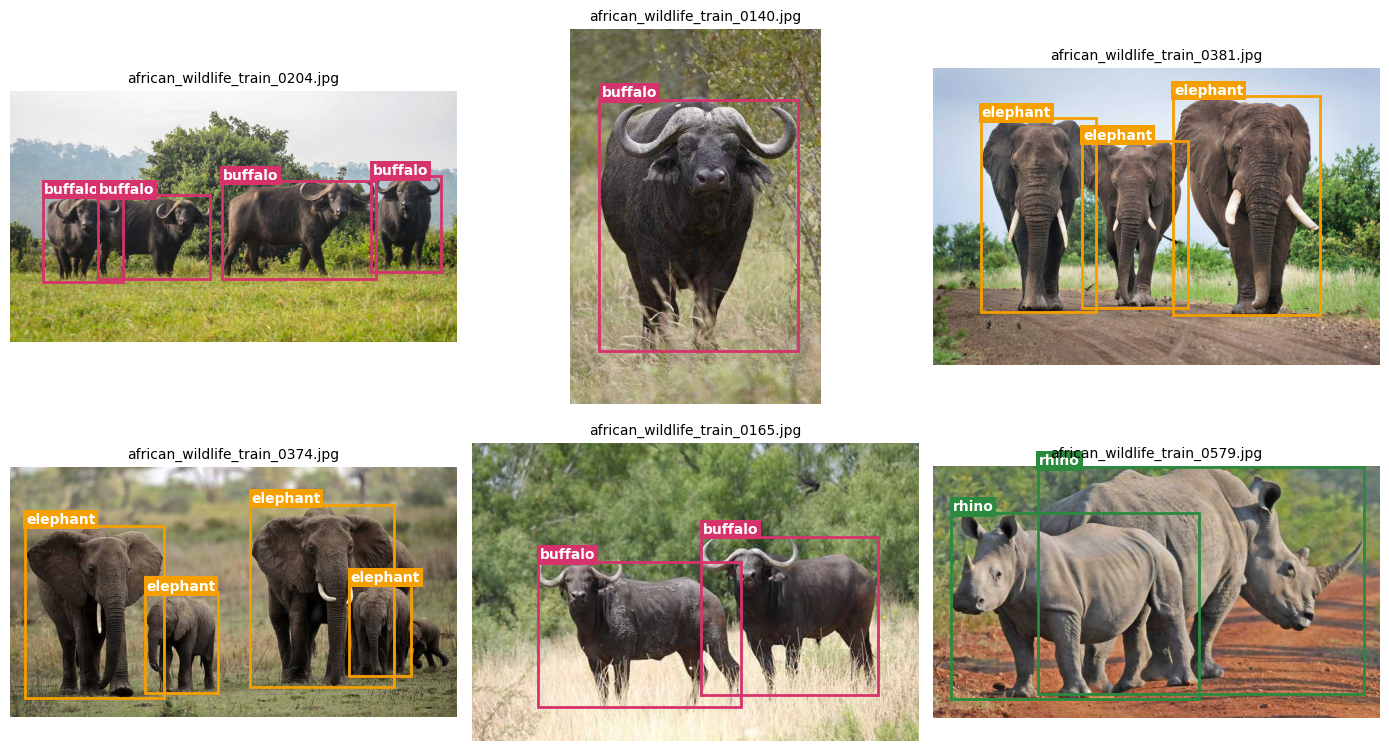

In [3]:
import yaml
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

classes = cfg["names"]
if isinstance(classes, dict):
    # Ultralytics accepts both list and dict forms — normalise.
    classes = [classes[i] for i in sorted(classes.keys())]
print(f"Classes: {classes}")

CLASS_COLOURS = {
    0: "#d6336c", 1: "#f59f00", 2: "#2b8a3e", 3: "#1c7ed6",
}

dataset_root = Path(cfg["path"])
train_imgs = sorted((dataset_root / cfg["train"]).glob("*.jpg"))
train_lbls = dataset_root / cfg["train"].replace("images", "labels")

sample = random.Random(7144).sample(train_imgs, k=min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, img_path in zip(axes.flat, sample):
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img); ax.axis("off"); ax.set_title(img_path.name, fontsize=10)
    lbl_path = train_lbls / f"{img_path.stem}.txt"
    if lbl_path.is_file():
        for line in lbl_path.read_text().splitlines():
            if not line.strip(): continue
            cls, cx, cy, w, h = line.split()
            cls = int(cls); cx, cy, w, h = map(float, (cx, cy, w, h))
            x = (cx - w/2) * W; y = (cy - h/2) * H
            colour = CLASS_COLOURS.get(cls, "#888")
            ax.add_patch(patches.Rectangle((x, y), w*W, h*H,
                                            linewidth=2, edgecolor=colour, facecolor="none"))
            ax.text(x+3, y-4, classes[cls], color="white", fontsize=10, fontweight="bold",
                    bbox=dict(boxstyle="square,pad=0.2", facecolor=colour, edgecolor="none"))
plt.tight_layout()
plt.show()

## 3. What is YOLO actually doing?

Before we run `model.train()` and get a blizzard of metrics, let's anchor the conceptual move from classification to detection.

<img src="assets/yolo_concept.svg" alt="Classification vs detection" width="880"/>

**Classification** (Labs 3–5) takes one image and produces *one* label — a single softmax over class probabilities. There's no concept of *where* anything is.

**Detection** (Lab 7) takes one image and produces *a variable number* of bounding boxes, each with its own class id and confidence score. The model must learn to:

1. **Localise** — predict where every object is, as (cx, cy, w, h).
2. **Classify** — predict what each object is.
3. **Count** — implicitly, decide how many objects exist (zero is also a valid answer).

YOLO's contribution, in 2016, was to do all of this in a **single forward pass** of one neural network — hence "You Only Look Once". Before YOLO, detection used two-stage pipelines (R-CNN, Faster R-CNN) that proposed regions first, then classified them. YOLO collapsed it into one.

**YOLO26's headline improvements** over earlier versions:

- **End-to-end NMS-free inference.** Older YOLO models produced many overlapping predictions per object, then ran non-maximum suppression (NMS) as a post-processing step to pick the best ones. YOLO26 (following YOLOv10) trains the network itself to produce de-duplicated predictions directly. Faster inference, simpler deployment.
- **MuSGD optimizer.** A hybrid of SGD and the Muon optimizer (originally developed for large language model training). More stable convergence than Adam or pure SGD on detection tasks.
- **ProgLoss + STAL.** Specific loss functions designed to improve small-object detection performance.

## 4. Object detection metrics

Detection has its own evaluation vocabulary, distinct from classification. You met IoU in Lab 6 — it's the foundation.

**IoU (Intersection over Union):** for any predicted box and any ground-truth box, IoU is the overlap area divided by the union area. Range 0 (no overlap) to 1 (perfect overlap). A prediction is counted as a 'true positive' if it overlaps an as-yet-unmatched ground-truth box with IoU above a threshold; otherwise it's a 'false positive'. Any ground-truth box that never gets matched is a 'false negative' — a miss. There is no 'true negative' in detection, which matters later (Section 7).

**Precision & recall, per class:**
- *Precision* = of the boxes the model predicts, what fraction match a real object?
- *Recall* = of the real objects, what fraction does the model find?

**mAP50 (mean Average Precision at IoU 0.50):** the standard 'one number for detection quality'. It varies the model's confidence threshold from 0 to 1, plots precision vs recall, takes the area under the curve, averages across classes. mAP50 = 0.9 means the model is very good at finding objects with reasonable localisation.

**mAP50-95 (mean Average Precision averaged across IoU thresholds 0.50 to 0.95):** a *much* stricter metric. It computes AP at IoU = 0.50, 0.55, 0.60, ..., 0.95, and averages all ten. mAP50-95 = 0.9 means the model not only finds the objects but localises them *very precisely*. This is the headline metric in the COCO benchmark and the one Ultralytics reports as the main score.

**Why mAP50-95 matters.** A model that can find an elephant but draws sloppy boxes (50-60% IoU) will score well on mAP50 but poorly on mAP50-95. For applications where the *box* matters (counting, measuring, cropping), the latter is what you care about. For 'is there an elephant in this image at all' applications, mAP50 is enough.

## 5. Loading a pretrained YOLO26x model

We start from a **pretrained checkpoint** — `yolo26x.pt`, which was trained on the COCO dataset (80 everyday object classes including 'dog', 'horse', 'bird', 'sheep'). We then *fine-tune* it on our 4-class African wildlife dataset. This is the canonical transfer-learning move: the lower layers have already learned generic visual features that transfer to almost any natural-image task, and we only need to retrain the head and adjust the rest slightly.

**Why YOLO26x and not a smaller variant?** Because you specified the requirement, and because our dataset is now large enough (1,052 training images) that a large model is a legitimate choice rather than pure overkill. The size variants are:

| Variant      | Params | Best for |
|--------------|--------|----------|
| `yolo26n.pt` | ~3M    | Edge devices, real-time on CPU |
| `yolo26s.pt` | ~10M   | Mobile, faster training |
| `yolo26m.pt` | ~25M   | Balanced |
| `yolo26l.pt` | ~45M   | Server-side, higher accuracy |
| `yolo26x.pt` | ~70M   | Maximum accuracy, GPU required |

We're here to learn the workflow at full scale, so x it is — but exactly how much the size choice matters *at this dataset size* is genuinely an open question. Exercise 2 checks it directly.

In [4]:
from ultralytics import YOLO

# First time you run this, Ultralytics downloads yolo26x.pt (~280 MB) to the
# current working directory. Subsequent runs use the cached file.
model = YOLO("yolo26x.pt")

print(f"Model type: {type(model).__name__}")
print(f"Task:       {model.task}")
n_params = sum(p.numel() for p in model.model.parameters())
print(f"Parameters: {n_params:,}")

WARNING ⚠️ user config directory '/workspace/.ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model type: YOLO
Task:       detect
Parameters: 58,993,368


## 6. Training

Now the headline event. The Ultralytics `model.train()` call hides a lot of machinery — augmentation, batching, optimizer scheduling, validation, checkpointing — behind one method. We will walk through every parameter.

> ⏱ **Time estimate.** On a 3090/4090/5090, 50 epochs on the full 1,052-image training set takes roughly 60–120 minutes, depending on GPU and exact settings — plan your lab session around this. Early stopping (`patience=20` below) will cut this short if validation mAP plateaus before epoch 50. If you set `DATASET_CHOICE = "own"` and train on your 24-image Lab 6 pool instead, expect 3–5 minutes — and a much worse model, which is rather the point. The first epoch is always slower than the rest because Ultralytics does initial setup and dataset caching.

**Parameters explained:**

- `data` — path to your `data.yaml`.
- `epochs=50` — how many full passes over the training set.
- `imgsz=640` — resize all input images to 640×640 for training. YOLO is fully convolutional so it would handle other sizes, but 640 is the canonical size for the COCO pretrained weights.
- `batch=16` — batch size. For yolo26x at 640×640, this uses about 14-18 GB of VRAM. **Reduce to 8 if you OOM**, increase to 32 on a 32GB GPU like the 5090.
- `device=0` — use GPU 0. Use `[0, 1]` for multi-GPU.
- `project` and `name` — where Ultralytics writes outputs. We pin this to a known location.
- `patience=20` — Ultralytics' built-in early stopping. Stops if validation metric stops improving for 20 epochs.
- `seed=7144` — module-wide reproducibility convention.
- `verbose=True` — show the per-epoch metrics.

In [7]:
import time

t0 = time.perf_counter()
results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="runs",
    name="african_wildlife",
    exist_ok=True,    # overwrite if previous run is in that folder
    patience=20,
    seed=7144,
    verbose=True,
    pretrained=True,
)
elapsed = time.perf_counter() - t0
print(f"\nTraining done in {elapsed/60:.1f} minutes.")
print(f"Results saved to: {results.save_dir}")

Ultralytics 8.4.45 🚀 Python-3.11.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/labs/lab06_image_annotation/data/full_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=african_wildlife, nbs=64, nms=False, opset=None, optim

## 7. What did Ultralytics write to disk?

Ultralytics produces a lot of output. Knowing what's where is the difference between feeling overwhelmed and feeling productive.

In [8]:
run_dir = Path(results.save_dir)
print(f"Training run directory: {run_dir}\n")
for p in sorted(run_dir.iterdir()):
    if p.is_file():
        size = p.stat().st_size
        print(f"  {p.name:<35s} {size/1024:.0f} KB")
    elif p.is_dir():
        n = sum(1 for _ in p.iterdir())
        print(f"  {p.name}/ ({n} files)")

Training run directory: /workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife

  BoxF1_curve.png                     158 KB
  BoxPR_curve.png                     117 KB
  BoxP_curve.png                      126 KB
  BoxR_curve.png                      156 KB
  args.yaml                           2 KB
  confusion_matrix.png                124 KB
  confusion_matrix_normalized.png     142 KB
  labels.jpg                          261 KB
  results.csv                         6 KB
  results.png                         286 KB
  train_batch0.jpg                    665 KB
  train_batch1.jpg                    678 KB
  train_batch2.jpg                    752 KB
  train_batch2640.jpg                 497 KB
  train_batch2641.jpg                 545 KB
  train_batch2642.jpg                 519 KB
  val_batch0_labels.jpg               462 KB
  val_batch0_pred.jpg                 468 KB
  val_batch1_labels.jpg               553 KB
  val_batch1_pred.jpg                 560 KB
  val_bat

Key files:

- **`weights/best.pt`** — the model checkpoint with the best validation mAP across all epochs. This is the model you deploy.
- **`weights/last.pt`** — the most-recent checkpoint, useful for resuming a stopped run.
- **`results.png`** / **`results.csv`** — training curves (loss, precision, recall, mAP per epoch).
- **`confusion_matrix.png`** — class-vs-class confusion at the chosen confidence threshold.
- **`PR_curve.png`** — precision-recall curve, one line per class, averaged for mAP.
- **`labels.jpg`** / **`labels_correlogram.jpg`** — dataset diagnostics (class distribution, bounding-box size distribution).
- **`train_batchN.jpg`** / **`val_batchN_pred.jpg`** — augmented training batches and prediction batches for visual inspection.

Let's look at the training curves first.

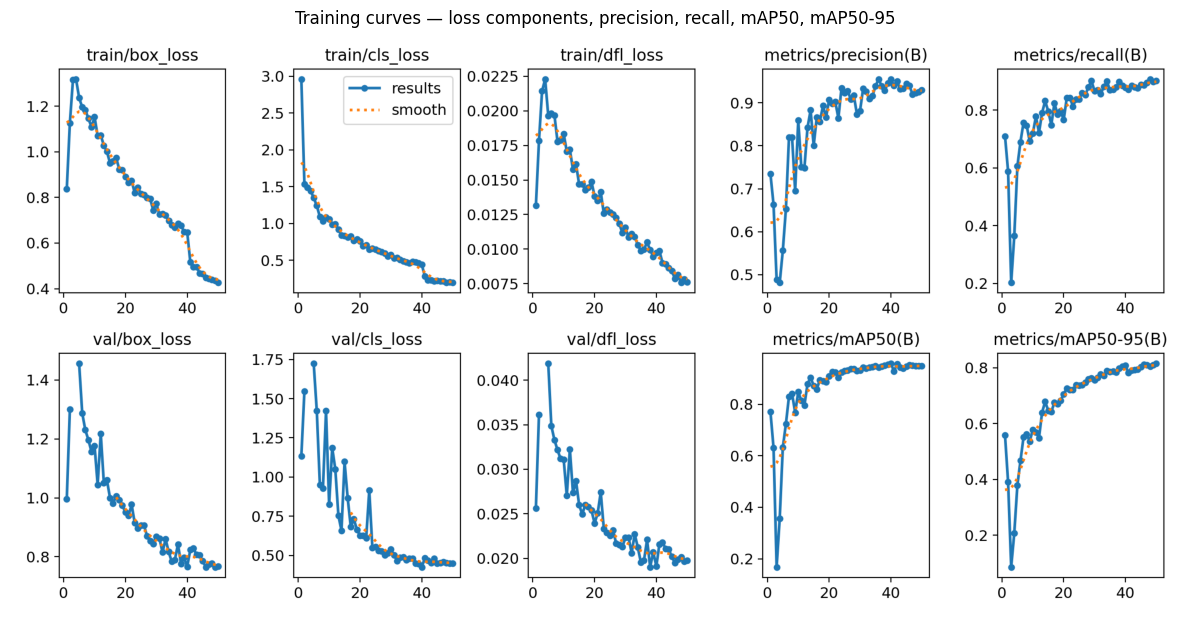

In [9]:
fig, ax = plt.subplots(figsize=(12, 9))
img = Image.open(run_dir / "results.png")
ax.imshow(img); ax.axis("off")
ax.set_title("Training curves — loss components, precision, recall, mAP50, mAP50-95")
plt.tight_layout(); plt.show()

**What to look for in the training curves:**

- *Box loss* and *cls loss* (top row) should both fall steadily — these are the two components of the detection loss.
- *Precision* should rise toward 1.0. *Recall* should also rise — these are class-aggregated.
- *mAP50* and *mAP50-95* (bottom row) tell the headline story. They should rise and then plateau.
- **If validation metrics plateau much lower than training metrics, you're overfitting.** On the full 1,052-image dataset this is possible but not guaranteed — a real, moderately-sized dataset gives the model enough to generalise from. If you trained on your own 24-image Lab 6 pool instead (`DATASET_CHOICE = "own"`), it almost certainly *will* happen — that's a teaching limitation of small datasets, not a modelling failure.

## 8. Validation on the held-out test set

Ultralytics ran validation *during* training (on the `val` split, against the best weights). Now we explicitly run it again on the `test` split — the data the model has never seen and we haven't used for early stopping. This is the honest evaluation.

In [10]:
# Load the best checkpoint.
best_model = YOLO(str(run_dir / "weights" / "best.pt"))

# Evaluate on the test split (the `split` argument selects which entry in data.yaml to use).
metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    device=0,
    project="runs",
    name="african_wildlife_test",
    exist_ok=True,
    verbose=False,
)

print("\nHeadline metrics on test split:")
print(f"  Precision (mean): {metrics.box.mp:.4f}")
print(f"  Recall (mean):    {metrics.box.mr:.4f}")
print(f"  mAP50:            {metrics.box.map50:.4f}")
print(f"  mAP50-95:         {metrics.box.map:.4f}")

print("\nPer-class mAP50-95:")
for i, class_name in enumerate(classes):
    if i < len(metrics.box.maps):
        print(f"  {class_name:<10s} {metrics.box.maps[i]:.4f}")

Ultralytics 8.4.45 🚀 Python-3.11.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
YOLO26x summary (fused): 190 layers, 55,638,168 parameters, 0 gradients, 193.4 GFLOPs
val: Fast image access ✅ (ping: 1.0±0.1 ms, read: 25.8±10.3 MB/s, size: 42.5 KB)
val: Scanning /workspace/labs/lab06_image_annotation/data/full_dataset/labels/test.cache... 227 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 227/227 105.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 7.8it/s 1.9s0.1s
                   all        227        375      0.972      0.942       0.98      0.858
Speed: 1.1ms preprocess, 4.0ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife_test

Headline metrics on test split:
  Precision (mean): 0.9721
  Recall (mean):    0.9420
  mAP50:            0.9795
  mAP50-95:         0.8576

Per-class mAP50-95:
  buffa

### Confusion matrix

Ultralytics also writes a class-confusion plot. For detection problems this is *slightly* different from a classification confusion matrix — it includes a 'background' row/column for cases where the model predicted a box where there's nothing (false positive) or missed a box that was there (false negative).

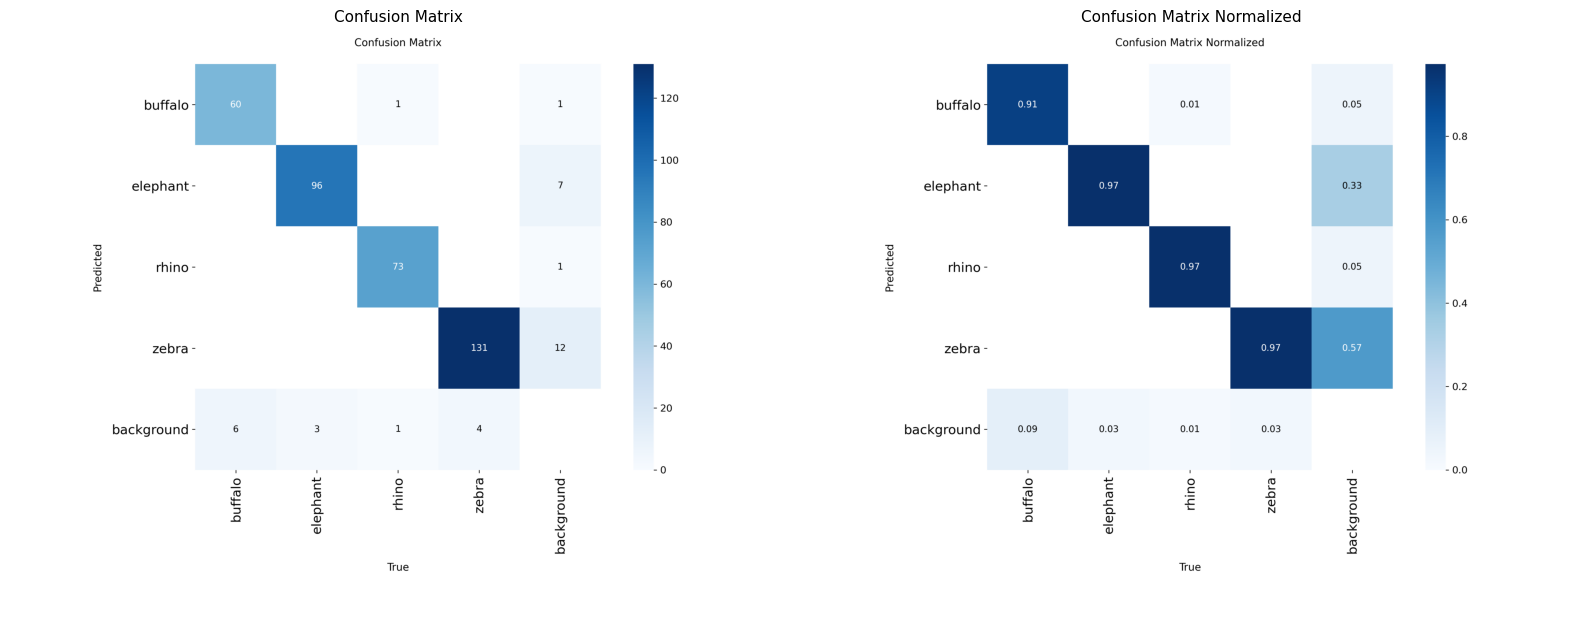

In [11]:
# Use Ultralytics' authoritative output dir rather than guessing the path.
# Recent versions sometimes write 'confusion_matrix_normalized.png' instead of
# (or alongside) 'confusion_matrix.png', so we glob for any match.
test_run_dir = Path(metrics.save_dir)
cm_paths = sorted(test_run_dir.glob("confusion_matrix*.png"))

if cm_paths:
    fig, axes = plt.subplots(1, len(cm_paths), figsize=(8 * len(cm_paths), 7))
    if len(cm_paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, cm_paths):
        ax.imshow(Image.open(p)); ax.axis("off")
        ax.set_title(p.stem.replace("_", " ").title(), fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print(f"No confusion matrix files found in {test_run_dir}. Other files there:")
    for f in sorted(test_run_dir.iterdir()):
        print(f"  {f.name}")

## 9. Inference on new images

The real test is: can the model find animals in images it has never seen? We bundle three held-out test images in `test_images/` for this purpose. You can also drop your own JPEGs into that folder.

`model.predict()` accepts a single image path, a directory, a list of paths, or even a URL or video file.

In [12]:
test_image_dir = Path("test_images")
test_paths = sorted(test_image_dir.glob("*.jpg"))
print(f"Will predict on {len(test_paths)} images:")
for p in test_paths: print(f"  {p.name}")

predictions = best_model.predict(
    source=[str(p) for p in test_paths],
    imgsz=640,
    conf=0.25,       # ignore predictions below 25% confidence
    device=0,
    save=True,       # write annotated images to disk
    project="runs",
    name="african_wildlife_predict",
    exist_ok=True,
    verbose=False,
)

print(f"\nAnnotated images written to: runs/african_wildlife_predict/")

Will predict on 3 images:
  test1_trio.jpg
  test2_tiny.jpg
  test3_edge.jpg
Results saved to /workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife_predict

Annotated images written to: runs/african_wildlife_predict/


Predict dir: /workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife_predict


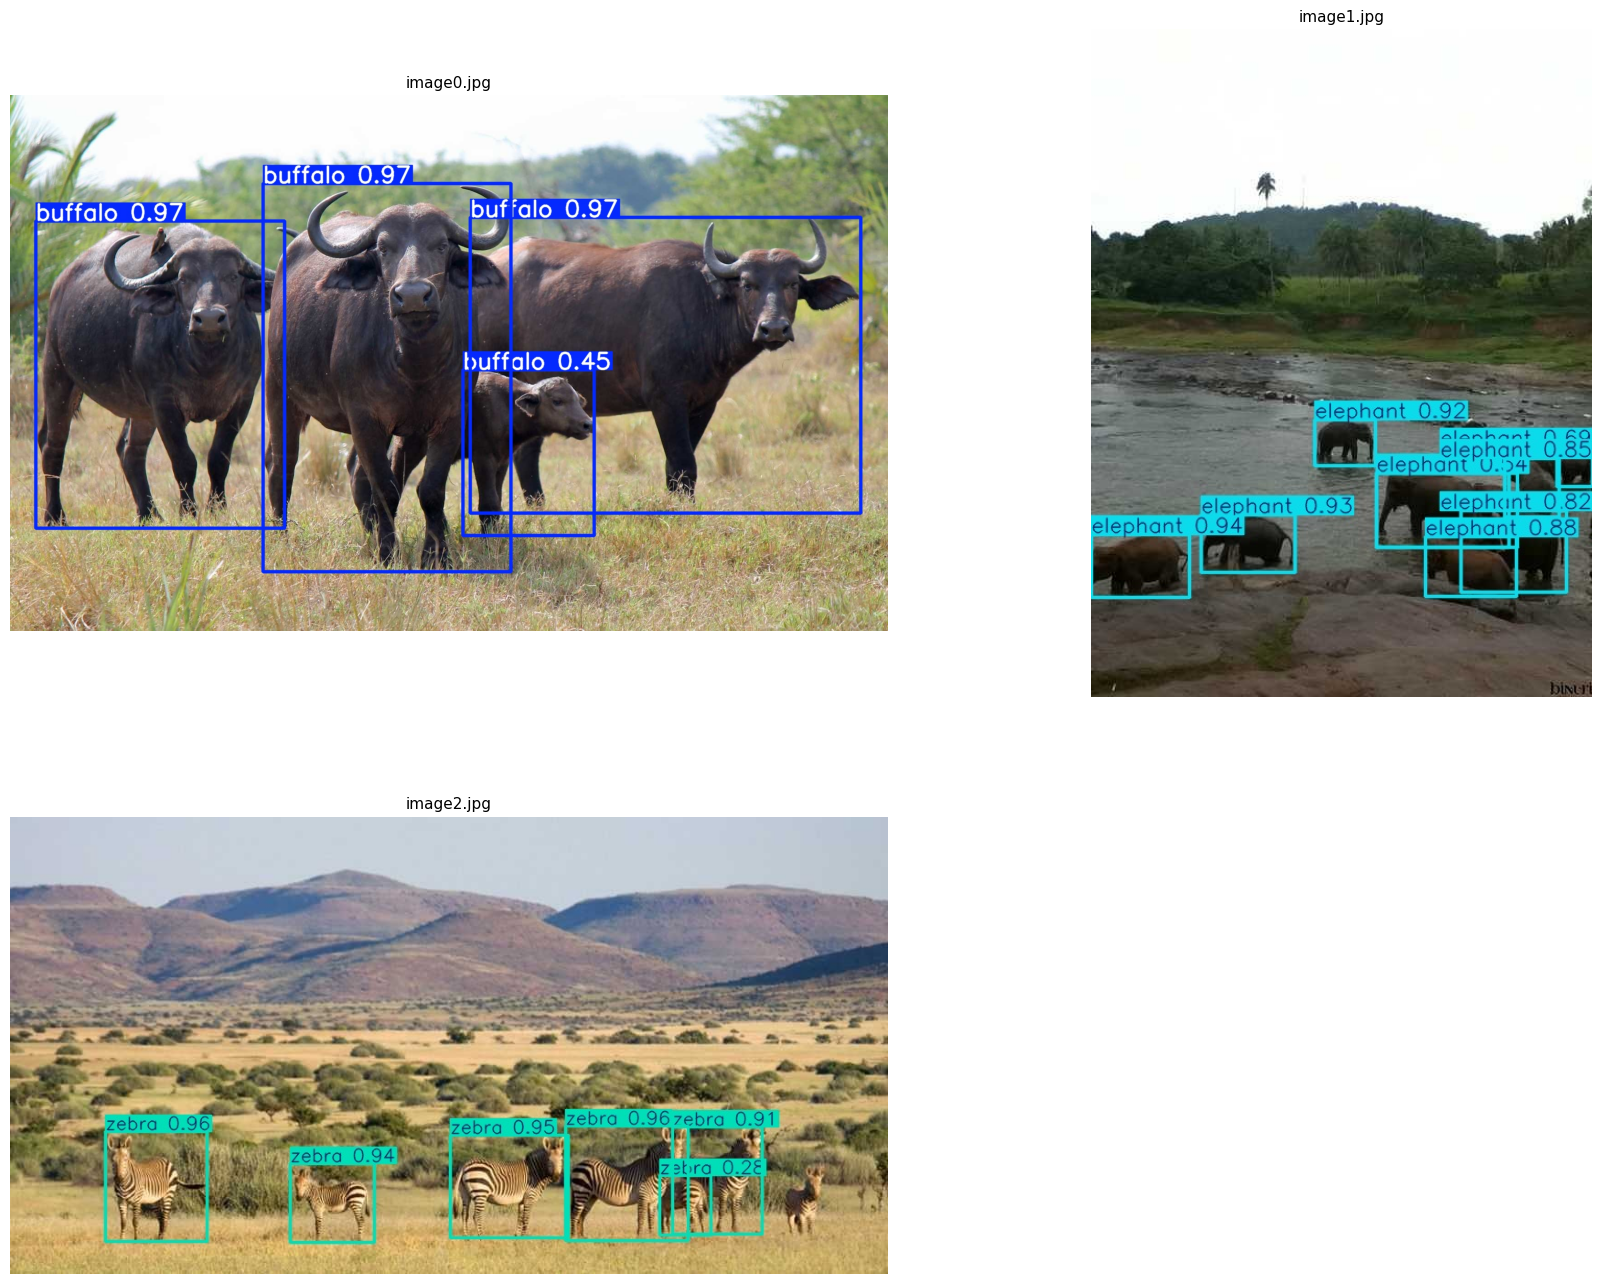

In [13]:
import numpy as np
# Use Ultralytics' authoritative save_dir from the predict results, not a guessed path.
predict_dir = Path(predictions[0].save_dir) if predictions else None
print(f"Predict dir: {predict_dir}")

annotated = []
if predict_dir and predict_dir.is_dir():
    # Catch both jpg and png — Ultralytics' save format varies by source.
    annotated = sorted(list(predict_dir.glob("*.jpg")) + list(predict_dir.glob("*.png")))

if not annotated:
    print("No annotated images found. Diagnostic listing:")
    if predict_dir and predict_dir.is_dir():
        for f in sorted(predict_dir.iterdir()):
            print(f"  {f.name}")
else:
    # 2-per-row grid so each image is large enough to read.
    N_COLS = 2
    n_rows = (len(annotated) + N_COLS - 1) // N_COLS
    fig, axes = plt.subplots(n_rows, N_COLS, figsize=(9 * N_COLS, 7 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for ax, p in zip(axes, annotated):
        ax.imshow(Image.open(p)); ax.axis("off"); ax.set_title(p.name, fontsize=11)
    for ax in axes[len(annotated):]:
        ax.set_visible(False)
    plt.tight_layout(); plt.show()

In [14]:
# Inspect the predictions structurally — useful for downstream work.
for r in predictions:
    print(f"\n{Path(r.path).name}")
    if r.boxes is None or len(r.boxes) == 0:
        print("  (no detections)")
        continue
    boxes = r.boxes.xyxyn.cpu().numpy()       # normalised xyxy
    confs = r.boxes.conf.cpu().numpy()
    cls_ids = r.boxes.cls.cpu().numpy().astype(int)
    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        print(f"  {classes[cls_ids[i]]:<10s} conf={confs[i]:.3f}  "
              f"xyxy=({x1:.3f}, {y1:.3f}, {x2:.3f}, {y2:.3f})")


image0.jpg
  buffalo    conf=0.972  xyxy=(0.029, 0.237, 0.313, 0.808)
  buffalo    conf=0.971  xyxy=(0.288, 0.167, 0.571, 0.889)
  buffalo    conf=0.967  xyxy=(0.524, 0.230, 0.969, 0.780)
  buffalo    conf=0.450  xyxy=(0.516, 0.514, 0.665, 0.822)

image1.jpg
  elephant   conf=0.939  xyxy=(0.001, 0.756, 0.197, 0.851)
  elephant   conf=0.932  xyxy=(0.220, 0.727, 0.407, 0.814)
  elephant   conf=0.919  xyxy=(0.447, 0.586, 0.568, 0.654)
  elephant   conf=0.876  xyxy=(0.667, 0.760, 0.849, 0.850)
  elephant   conf=0.854  xyxy=(0.827, 0.643, 0.934, 0.731)
  elephant   conf=0.821  xyxy=(0.739, 0.722, 0.948, 0.843)
  elephant   conf=0.688  xyxy=(0.930, 0.625, 1.000, 0.685)
  elephant   conf=0.535  xyxy=(0.569, 0.665, 0.850, 0.776)
  elephant   conf=0.302  xyxy=(0.570, 0.665, 0.834, 0.775)

image2.jpg
  zebra      conf=0.956  xyxy=(0.108, 0.690, 0.225, 0.929)
  zebra      conf=0.955  xyxy=(0.633, 0.676, 0.772, 0.926)
  zebra      conf=0.953  xyxy=(0.501, 0.697, 0.636, 0.921)
  zebra      conf=0.

## 10. Export for deployment

When you want to run the trained model in production — on a server, on an edge device, in a non-Python language — you typically export it to a deployment-friendly format. **ONNX** (Open Neural Network Exchange) is the most portable: every major inference runtime supports it.

Ultralytics makes export a one-liner.

In [15]:
onnx_path = best_model.export(format="onnx", imgsz=640, simplify=True)
print(f"Exported model to: {onnx_path}")
print(f"Size: {Path(onnx_path).stat().st_size / 1e6:.1f} MB")

Ultralytics 8.4.45 🚀 Python-3.11.15 torch-2.11.0+cu128 CPU (Intel Core Ultra 9 285K)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (112.8 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
WARNING ⚠️ requirements: ❌ AutoUpdate skipped (offline)

ONNX: starting export with onnx 1.17.0 opset 20...


/usr/local/lib/python3.11/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


WARNING ⚠️ ONNX: simplifier failure: No module named 'onnxslim'
ONNX: export success ✅ 2.9s, saved as '/workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife/weights/best.onnx' (212.5 MB)

Export complete (4.0s)
Results saved to /workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife/weights
Predict:         yolo predict task=detect model=/workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife/weights/best.onnx imgsz=640 data=/workspace/labs/lab06_image_annotation/data/full_dataset/data.yaml  
Visualize:       https://netron.app
Exported model to: /workspace/labs/lab07_yolo_training/runs/detect/runs/african_wildlife/weights/best.onnx
Size: 222.9 MB


**What you can do with the ONNX file:**

- Load it in **onnxruntime** for CPU or GPU inference without PyTorch.
- Convert it to **TensorRT** for maximum speed on NVIDIA hardware (`yolo export format=engine`).
- Convert it to **CoreML** for iOS deployment, **TFLite** for Android, or **OpenVINO** for Intel hardware.
- Inspect the graph in [Netron](https://netron.app/) to understand the architecture.

Verification that the ONNX file actually works follows the same pattern you'd use for any ONNX model:

In [16]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
input_meta = session.get_inputs()[0]
output_meta = session.get_outputs()[0]
print(f"ONNX input:  {input_meta.name}  shape {input_meta.shape}  dtype {input_meta.type}")
print(f"ONNX output: {output_meta.name} shape {output_meta.shape}")

# Quick smoke test: a single zero input shouldn't crash.
dummy = np.zeros((1, 3, 640, 640), dtype=np.float32)
out = session.run(None, {input_meta.name: dummy})
print(f"ONNX dummy inference: output shape {out[0].shape}")

ONNX input:  images  shape [1, 3, 640, 640]  dtype tensor(float)
ONNX output: output0 shape [1, 300, 6]
ONNX dummy inference: output shape (1, 300, 6)


---

## 11. Exercise 1 — explore hyperparameters

Pick **one** hyperparameter and study its effect. Train two additional runs (one above the baseline, one below), record the test mAP50-95 for each, and write 3–5 sentences interpreting the result.

**Choose one of:**

- **`imgsz`** — try `imgsz=320` and `imgsz=1280`. Bigger images = more detail captured but slower. How much does image size affect performance on this dataset?
- **`epochs`** — try `epochs=20` and `epochs=100`. Where does the model start overfitting (val mAP rises then falls)?
- **`batch`** — try `batch=4` and `batch=32`. Does batch size affect *final* accuracy, or just *training stability and wall-clock*?
- **`lr0`** — try `lr0=0.001` (10× lower) and `lr0=0.05` (5× higher) than Ultralytics' default. Does either extreme break training?

*Each extra training run takes a few minutes on a GPU. Plan accordingly.*

In [ ]:
# Your code for Exercise 1 here.


*Which hyperparameter did you pick? What did you find?*




## 12. Exercise 2 — model size matters

We trained `yolo26x` (~70M parameters) on the full, real 1,052-image dataset this time — a far more reasonable amount of data for a model this size than a 24-image toy set would be. Still, modern wisdom says: **always start with the smallest variant** and only go larger if you can show the small one is the bottleneck.

Re-train using **`yolo26n.pt`** (~3M parameters, 20× smaller) with the **same hyperparameters** and the **same data**. Report:

**(a)** Test mAP50-95 — does the smaller model actually do worse on our real dataset, or roughly the same?

**(b)** Wall-clock training time.

**(c)** Inference time per image (run `predict()` on the same test image with both models, measure with `time.perf_counter()`).

**(d)** Write a paragraph (4–6 sentences) on when you would and wouldn't choose the larger variant in practice. Consider: dataset size, deployment target, latency requirements, compute budget.

In [ ]:
# Your code for Exercise 2 here.


*Your written analysis:*



## 13. Exercise 3 — open-ended (pick one)

**Pick *one* and complete it fully.**

### Option A — Confidence threshold sweep

Just as in Lab 2's medical-screening exercise, the decision threshold matters. Re-run `predict()` on the test images at confidence thresholds 0.10, 0.25, 0.50, 0.75. For each, count:

- True positives (predictions that match a ground-truth box with IoU > 0.5)
- False positives (predictions with no matching ground truth)
- False negatives (ground-truth boxes with no matching prediction)

Plot precision vs recall across the four thresholds. Which threshold would you use if you were building a wildlife monitoring system where missing a rhino is much worse than over-reporting one — as it might be for an anti-poaching alert system, where a missed rhino is a real animal nobody is watching?

### Option B — Predict on a video

YOLO can process video. Either download a short clip of African wildlife (Wikimedia Commons has many CC-licensed options) or use any suitable video you have. Save it as `test_images/clip.mp4`. Then:

```python
results = best_model.predict(source="test_images/clip.mp4", save=True, conf=0.25)
```

Ultralytics will write an annotated video to `runs/african_wildlife_predict/clip.avi`. Watch it. Comment on:

1. Frame-to-frame stability — does the same object get the same class id across consecutive frames?
2. The 'flicker' problem — boxes that appear and disappear between frames.
3. Whether you'd want object *tracking* (persistent ids across frames) on top of detection.

### Option C — Does more hand-annotated data help at this scale?

Merge your own 24 hand-annotated images from Lab 6 into the full training set — copy them (images and labels) into `full_dataset/images/train` and `full_dataset/labels/train`, being careful not to overwrite anything, build a merged `data.yaml`, and retrain.

Compare the test mAP against the un-merged run from earlier in this lab. Most people find the difference is small, possibly within noise. Reflect: given the full dataset already has 1,052 training images, why would 24 more barely move the needle — and at roughly what dataset size *would* 24 additional annotated images make a real difference? What does this say about diminishing returns in data collection?

In [ ]:
# Your code for Exercise 3 (Option A, B, or C) here.


*Which option did you pick?*


*Your written reflection:*



## 14. Reflection questions

**Q1.** Explain in your own words what 'pretrained on COCO' means. Why is it usually a better starting point for a new detection task than training from random weights?

**Q2.** YOLO26 is *end-to-end NMS-free*. Older YOLO models needed a post-processing step called non-maximum suppression. Briefly: what problem does NMS solve, and what is the practical benefit of training a network that no longer needs it?

**Q3.** Section 2 gave you the option to train on your own 24-image Lab 6 pool instead of the full 1,052-image dataset (`DATASET_CHOICE = "own"`). Without necessarily running it, predict what you'd expect to see in the training curves and the final test mAP compared to the full-dataset run, and explain why. If you have time, actually run it and check your prediction.

**Q4.** Look at the per-class mAP50-95 you printed in Section 8. Which class scored worst on your run? Suggest one specific, concrete change you'd try first to improve it — be specific rather than just saying 'more data'.

**Q5.** Ultralytics ships YOLO26 under the **AGPL-3.0** license. Suppose you wanted to deploy your trained model as the inference engine behind a paid wildlife-monitoring SaaS product. What's the legal/practical concern, and what are your options? (You're not a lawyer; a 3-sentence answer is fine.)

*Your answers:*

**A1.** 

**A2.** 

**A3.** 

**A4.** 

**A5.** 

---

## What's next

You've now trained a real, production-grade object detector end-to-end. The pipeline you used is the same one that ships wildlife cameras, traffic monitoring systems, factory floor inspection, and a hundred other applications.

**Lab 8** turns to the question every trained model eventually has to answer honestly: *how good is it, really?* The metrics Ultralytics printed above came from a test split drawn from the same pool as your training data — flattering, but not the whole story. You'll build an independent ground-truth test set, compute precision, recall, and mAP **from first principles** rather than trusting a library's output blindly, and learn why the ROC curve — a tool you may already know from classification — doesn't apply to object detection at all.

Before leaving today, make sure:

- [ ] Training completed successfully on the GPU
- [ ] You have completed Exercises 1, 2, and 3
- [ ] You have answered the reflection questions
- [ ] Your notebook runs **top to bottom without errors** (*Kernel → Restart and Run All*)
- [ ] `runs/african_wildlife/weights/best.pt` exists and is the model you'd deploy
- [ ] An ONNX export was produced successfully